# Stage 2 — Image reconstruction with a Gaussian PSF and uncorrelated noise

This stage starts from the noiseless lensed cubes defined by `mock_truth.toml`, convolves every image-plane channel with a known elliptical Gaussian PSF, adds independent Gaussian noise, and compares physical mass models with and without a Hernquist bulge using `dynesty`. The comparison statistic is $\Delta\ln Z = \ln Z_{\rm bulge}-\ln Z_{\rm no\ bulge}$.

1. Read the common mock truth and the Stage 2 fit settings.
2. Generate an intrinsic source cube from the physical mass model.
3. Apply the fixed or sampled lens parameters to make an image-plane cube.
4. Convolve each channel with the Gaussian PSF and add independent noise.
5. Reconstruct the cube with Dynamic Nested Sampling and compare the bulge and no-bulge evidence.

In [10]:
import os

# Each process runs one dynesty fit; prevent numerical libraries from creating nested thread pools.
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor
import hashlib
import json
import pickle
import time
import tomllib
from itertools import product
from pathlib import Path

import dynesty
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from dynesty import plotting as dyplot
from matplotlib.patches import Ellipse

%matplotlib inline

EXAMPLE_DIR = Path.cwd().resolve()
if not (
    EXAMPLE_DIR.name == 'examples'
    or (EXAMPLE_DIR.name == 'forward_mass' and EXAMPLE_DIR.parent.name == 'examples')
):
    raise FileNotFoundError('Run this notebook from examples/forward_mass or examples.')

from glint.beam import gaussian_psf_kernel
from glint import lensing
from glint.context import ImageContext
from glint.cosmology import critical_density, kpc_per_arcsec
from glint.forward import convolve_cube_spatial_cached, forward_model_3D_mass_intrinsic, mass_rotation_curve
from glint.inference import run_dynamic_dynesty
from glint.mass_model import r200_kpc_from_m200


## Diagnostic plotting helpers

These helper functions are defined before the experiment setup and called after sampling or cache loading. Generated files are written under `output/stage2/results/`.

In [11]:
def save_dynesty_diagnostic_plots():
    # runplotはevidenceの収束過程、cornerplotはposteriorとparameter縮退を確認する。
    for case in CASES:
        for model_name in ('no_bulge', 'bulge'):
            result = RESULTS[case['name']][model_name]
            result_dir = FIGURE_DIR / case['name'] / model_name
            result_dir.mkdir(parents=True, exist_ok=True)

            run_figure, _ = dyplot.runplot(result['results'], color='tab:blue', logplot=True)
            run_figure.suptitle(f"{case['name']} — {model_name}")
            run_path = result_dir / 'dynesty_runplot.pdf'
            run_figure.savefig(run_path, bbox_inches='tight')
            plt.close(run_figure)

            parameter_names = MODEL_FREE_NAMES[model_name]
            case_truth = truth_parameters(case)
            truths = [case_truth[name] for name in parameter_names]
            corner_figure, _ = dyplot.cornerplot(
                result['results'], labels=parameter_names, truths=truths,
                truth_color='tab:red', color='black', show_titles=True,
            )
            corner_figure.suptitle(f"{case['name']} — {model_name}")
            corner_path = result_dir / 'dynesty_cornerplot.pdf'
            corner_figure.savefig(corner_path, bbox_inches='tight')
            plt.close(corner_figure)
            print(f'saved {run_path.relative_to(EXAMPLE_DIR)} and {corner_path.relative_to(EXAMPLE_DIR)}')

### Channel-map and residual helper

The channel-map helper also computes reduced $\chi^2$ and standardized-residual statistics for every case/model.

In [12]:
def save_channel_diagnostics():
    # Maximum-likelihood modelを全channelで再計算し、dataとvoxel単位で比較する。
    diagnostic_rows = []
    image_extent = [axis.min(), axis.max(), axis.min(), axis.max()]
    source_extent = [XX_SOURCE_ARCSEC.min(), XX_SOURCE_ARCSEC.max(), YY_SOURCE_ARCSEC.min(), YY_SOURCE_ARCSEC.max()]
    field_width = axis.max() - axis.min()
    beam_x = axis.min() + 0.12 * field_width
    beam_y = axis.min() + 0.12 * field_width

    for case in CASES:
        mock = MOCKS[case['name']]
        data_cube = mock['data_cube']
        noise_sigma = mock['noise_sigma']
        for model_name in ('no_bulge', 'bulge'):
            result = RESULTS[case['name']][model_name]
            intrinsic_source_cube = intrinsic_cube(result['best_parameters'])
            model_cube = observed_model_cube(result['best_parameters'])
            residual_sigma_cube = (data_cube - model_cube) / noise_sigma
            # 正しいnoise modelなら、標準化残差の平均~0、標準偏差~1を期待する。
            fitted_residual = residual_sigma_cube[FIT_MASK]
            n_parameters = len(MODEL_FREE_NAMES[model_name])
            degrees_of_freedom = fitted_residual.size - n_parameters
            chi2 = float(np.sum(fitted_residual**2))
            reduced_chi2 = chi2 / degrees_of_freedom
            diagnostic_rows.append((
                case['name'], model_name, chi2, degrees_of_freedom, reduced_chi2,
                float(np.mean(fitted_residual)), float(np.std(fitted_residual)),
                float(np.max(np.abs(fitted_residual))),
            ))

            result_dir = FIGURE_DIR / case['name'] / model_name
            result_dir.mkdir(parents=True, exist_ok=True)
            n_channels = len(VELOCITY_CHANNELS_KMS)
            figure, axes = plt.subplots(n_channels, 4, figsize=(8.5, 1.65 * n_channels), squeeze=False)
            figure.subplots_adjust(wspace=0.02, hspace=0.02, top=0.96)
            observed_vmin = -2.0 * noise_sigma
            observed_vmax = max(float(np.max(data_cube)), float(np.max(model_cube)))
            source_vmax = float(np.max(intrinsic_source_cube))

            for channel_index, velocity_kms in enumerate(VELOCITY_CHANNELS_KMS):
                # 4列は観測data、PSF込みmodel、標準化残差、PSF前の復元source。
                panels = (
                    (data_cube[channel_index], 'magma', observed_vmin, observed_vmax),
                    (model_cube[channel_index], 'magma', observed_vmin, observed_vmax),
                    (residual_sigma_cube[channel_index], 'coolwarm', -5.0, 5.0),
                    (intrinsic_source_cube[channel_index], 'magma', 0.0, source_vmax),
                )
                for column, (panel, cmap, vmin, vmax) in enumerate(panels):
                    extent = source_extent if column == 3 else image_extent
                    axes[channel_index, column].imshow(panel, origin='lower', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
                    axes[channel_index, column].set_xticks([])
                    axes[channel_index, column].set_yticks([])
                axes[channel_index, 0].text(0.03, 0.92, f'{velocity_kms:+.0f} km/s', transform=axes[channel_index, 0].transAxes, color='white', fontsize=7, va='top')
                for column in (0, 1):
                    axes[channel_index, column].add_patch(Ellipse(
                        (beam_x, beam_y), width=CONFIG['psf']['fwhm_major_arcsec'],
                        height=CONFIG['psf']['fwhm_minor_arcsec'], angle=CONFIG['psf']['position_angle_deg'],
                        facecolor='white', edgecolor='black', linewidth=0.4,
                    ))

            for axis_object, title in zip(axes[0], ('True data (noisy)', 'Model data', r'Residual / $\sigma$', 'Reconstructed source'), strict=True):
                axis_object.set_title(title, fontsize=10)
            figure.suptitle(
                f"{case['name']} — {model_name}; reduced chi-square = {reduced_chi2:.3f}",
                fontsize=10,
                y=0.995,
            )
            channel_path = result_dir / 'all_channel_cube_comparison.pdf'
            figure.savefig(channel_path, bbox_inches='tight', pad_inches=0.03)
            plt.close(figure)
            print(f'saved {channel_path.relative_to(EXAMPLE_DIR)}')

    FIT_DIAGNOSTICS = Table(
        rows=diagnostic_rows,
        names=('case', 'model', 'chi2', 'dof', 'reduced_chi2', 'residual_mean_sigma', 'residual_std_sigma', 'max_abs_residual_sigma'),
    )
    for name in FIT_DIAGNOSTICS.colnames[2:]:
        FIT_DIAGNOSTICS[name].format = '.5g'
    diagnostics_path = OUTPUT_DIR / 'fit_diagnostics.csv'
    FIT_DIAGNOSTICS.write(diagnostics_path, format='ascii.csv', overwrite=True)
    display(FIT_DIAGNOSTICS)
    print(f'saved {diagnostics_path.relative_to(EXAMPLE_DIR)}')
    return FIT_DIAGNOSTICS

## Configuration and numerical grid

In [13]:
# mock_truth.tomlは全Stage共通、mock_stage2.tomlはPSF・noise・fit設定のみ。
with (EXAMPLE_DIR / 'mock_truth.toml').open('rb') as handle:
    TRUTH_CONFIG = tomllib.load(handle)
with (EXAMPLE_DIR / 'mock_stage2.toml').open('rb') as handle:
    CONFIG = tomllib.load(handle)

SOURCE_REDSHIFT = float(TRUTH_CONFIG['target']['redshift'])
KPC_PER_ARCSEC = kpc_per_arcsec(SOURCE_REDSHIFT)
RHO_CRITICAL_MSUN_KPC3 = critical_density(SOURCE_REDSHIFT)
mass_cfg = TRUTH_CONFIG['truth']['mass']
HALO_CONCENTRATION_200 = float(mass_cfg['halo_concentration_200'])
source_cfg = TRUTH_CONFIG['truth']['source']
lens_cfg = TRUTH_CONFIG['truth']['lens']
image_grid_cfg = TRUTH_CONFIG['grid']['image']
source_grid_cfg = TRUTH_CONFIG['grid']['source']
spectral_cfg = TRUTH_CONFIG['spectral']
radial_cfg = TRUTH_CONFIG['radial_profile']
noise_cfg, dynesty_cfg = CONFIG['noise'], CONFIG['dynesty']
parallel_cfg = CONFIG['parallel']
DYNESTY_WORKERS_PER_FIT = int(parallel_cfg.get('dynesty_workers_per_fit', 1))
if DYNESTY_WORKERS_PER_FIT < 1:
    raise ValueError('dynesty_workers_per_fit must be >= 1')
STAGE1_MANIFEST_PATH = EXAMPLE_DIR / 'output' / 'stage1' / 'products' / 'mock_manifest.json'
if not STAGE1_MANIFEST_PATH.exists():
    raise FileNotFoundError('Run Stage 1 first to create output/stage1/products/mock_manifest.json')
STAGE1_MANIFEST = json.loads(STAGE1_MANIFEST_PATH.read_text())
if STAGE1_MANIFEST.get('schema_version') != 1:
    raise ValueError('Unsupported Stage 1 manifest schema')
STAGE1_CASES = {case['name']: case for case in STAGE1_MANIFEST['cases']}

OUTPUT_DIR = EXAMPLE_DIR / 'output' / 'stage2' / 'results'
CACHE_DIR = OUTPUT_DIR / 'cache'
FIGURE_DIR = OUTPUT_DIR / 'figures'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# TOMLのfree parameter名を、forward modelの3グループに対応付ける。
MASS_PARAMETER_NAMES = ('log10_m_baryon', 'disk_scale_radius_kpc', 'log10_m200', 'bulge_to_total', 'bulge_effective_radius_kpc')
SOURCE_PARAMETER_NAMES = ('source_x_arcsec', 'source_y_arcsec', 'flux_normalization', 'inclination_deg', 'position_angle_deg', 'surface_brightness_scale_arcsec', 'velocity_dispersion_center_kms', 'velocity_dispersion_scale_arcsec', 'systemic_velocity_kms')
LENS_PARAMETER_NAMES = ('lens_x_arcsec', 'lens_y_arcsec', 'einstein_radius_arcsec', 'lens_axis_ratio', 'lens_position_angle_deg', 'log10_external_shear', 'external_shear_position_angle_deg', 'external_convergence')
ALL_PARAMETER_NAMES = MASS_PARAMETER_NAMES + SOURCE_PARAMETER_NAMES + LENS_PARAMETER_NAMES
MODEL_FREE_NAMES = {
    'bulge': tuple(CONFIG['fit']['free_parameters_bulge']),
    'no_bulge': tuple(CONFIG['fit']['free_parameters_no_bulge']),
}
BOUNDS = CONFIG['fit']['bounds']
# Parameter名の誤記やbounds不足をsampling開始前に検出する。
unknown = set().union(*MODEL_FREE_NAMES.values()) - set(ALL_PARAMETER_NAMES)
if unknown:
    raise ValueError(f'Unsupported fit parameters: {sorted(unknown)}')
missing_bounds = set().union(*MODEL_FREE_NAMES.values()) - set(BOUNDS)
if missing_bounds:
    raise ValueError(f'Missing bounds: {sorted(missing_bounds)}')

# Source planeは細かいgrid、image planeは観測画像に相当する広いgrid。
XX_SOURCE_ARCSEC, YY_SOURCE_ARCSEC = lensing.make_grid_arcsec(
    source_grid_cfg['grid_size'], source_grid_cfg['grid_size'],
    source_grid_cfg['pixel_size_arcsec'], source_grid_cfg['x_center_arcsec'], source_grid_cfg['y_center_arcsec'],
)
XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC = lensing.make_grid_arcsec(
    image_grid_cfg['grid_size'], image_grid_cfg['grid_size'],
    image_grid_cfg['pixel_size_arcsec'], image_grid_cfg['x_center_arcsec'], image_grid_cfg['y_center_arcsec'],
)
RADIUS_MAX_KPC = float(radial_cfg['radius_max_kpc'])
RADIAL_STEP_ARCSEC = float(radial_cfg['radial_step_arcsec'])
RADIAL_INTERVALS = int(np.ceil((RADIUS_MAX_KPC / KPC_PER_ARCSEC) / RADIAL_STEP_ARCSEC))
RADIUS_ARCSEC = np.arange(RADIAL_INTERVALS + 1) * RADIAL_STEP_ARCSEC
RADIUS_MAX_ARCSEC = RADIUS_ARCSEC[-1]
RADIUS_KPC = RADIUS_ARCSEC * KPC_PER_ARCSEC
VELOCITY_CHANNELS_KMS = np.arange(spectral_cfg['velocity_min_kms'], spectral_cfg['velocity_max_kms'] + 0.5 * spectral_cfg['channel_width_kms'], spectral_cfg['channel_width_kms'])
# Lensed emissionを十分に囲む円形apertureだけをlikelihoodに使う。
SPATIAL_MASK = np.hypot(XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC) <= CONFIG['image_fit']['fit_radius_arcsec']
FIT_MASK = np.broadcast_to(SPATIAL_MASK, (VELOCITY_CHANNELS_KMS.size, *SPATIAL_MASK.shape))
PSF_KERNEL = gaussian_psf_kernel(pixel_size_arcsec=image_grid_cfg['pixel_size_arcsec'], **CONFIG['psf'])
# 固定PSFのFFTを一度だけ計算し、全likelihood評価で再利用する。
PSF_CONTEXT = ImageContext(
    xx_img=XX_IMAGE_ARCSEC, yy_img=YY_IMAGE_ARCSEC,
    xx_src=XX_SOURCE_ARCSEC, yy_src=YY_SOURCE_ARCSEC,
    pixsize_img=image_grid_cfg['pixel_size_arcsec'],
    pixsize_src=source_grid_cfg['pixel_size_arcsec'], beam=PSF_KERNEL,
)
axis = XX_IMAGE_ARCSEC[0]

print(f'z={SOURCE_REDSHIFT:.3f}, scale={KPC_PER_ARCSEC:.4f} kpc/arcsec')
print(f'source cube={VELOCITY_CHANNELS_KMS.size} x {source_grid_cfg["grid_size"]} x {source_grid_cfg["grid_size"]}')
print(f'image cube={VELOCITY_CHANNELS_KMS.size} x {image_grid_cfg["grid_size"]} x {image_grid_cfg["grid_size"]}; fitted voxels={FIT_MASK.sum():,}')
print(f'PSF kernel={PSF_KERNEL.shape}, sum={PSF_KERNEL.sum():.8f}')
print(f'dynamic dynesty: nlive_init={dynesty_cfg["nlive_init"]}, nlive_batch={dynesty_cfg["nlive_batch"]}, pfrac={dynesty_cfg["pfrac"]}')
print(f'parallel: up to {parallel_cfg["max_workers"]} fits, '
      f'{DYNESTY_WORKERS_PER_FIT} Dynesty workers/fit')

z=6.024, scale=5.6972 kpc/arcsec
source cube=33 x 100 x 100
image cube=33 x 200 x 200; fitted voxels=1,320,000
PSF kernel=(19, 19), sum=1.00000000
dynamic dynesty: nlive_init=150, nlive_batch=100, pfrac=0.5
parallel: up to 1 fits, 16 Dynesty workers/fit


## Cases and forward model

Mock parameters come from `mock_truth.toml`. Parameters listed for each model in `mock_stage2.toml` are sampled; all remaining mass, source, and lens parameters stay fixed to truth. The default setup samples the mass parameters and fixes the lens and tracer geometry.

In [14]:
def case_name(bulge_to_total, bulge_effective_radius_kpc):
    return f'bt{round(100 * bulge_to_total):02d}_re{round(10 * bulge_effective_radius_kpc):02d}'

def make_cases():
    # B/Tとbulge半径の組合せを作り、mass scaleなどは全caseで共通にする。
    cases = [{
        'name': case_name(bt, re_kpc),
        'log10_m_baryon': np.log10(mass_cfg['total_baryonic_mass_msun']),
        'bulge_to_total': float(bt),
        'disk_scale_radius_kpc': float(mass_cfg['disk_scale_radius_kpc']),
        'bulge_effective_radius_kpc': float(re_kpc),
        'log10_m200': np.log10(mass_cfg['halo_mass_200_msun']),
    } for bt, re_kpc in product(mass_cfg['bulge_to_total_values'], mass_cfg['bulge_effective_radii_kpc'])]
    if mass_cfg.get('include_no_bulge_case', False):
        # B/T=0ではbulge半径は物理的に未定義。
        cases.append({
            'name': 'bt00',
            'log10_m_baryon': np.log10(mass_cfg['total_baryonic_mass_msun']),
            'bulge_to_total': 0.0,
            'disk_scale_radius_kpc': float(mass_cfg['disk_scale_radius_kpc']),
            # Undefined when the bulge mass is zero; the mass kernel returns before using it.
            'bulge_effective_radius_kpc': np.nan,
            'log10_m200': np.log10(mass_cfg['halo_mass_200_msun']),
        })
    return tuple(cases)

CASES = make_cases()

# 各caseのmass truthに、共通のsource・lens truthを加える。
def truth_parameters(case):
    return {
        **{name: float(case[name]) for name in MASS_PARAMETER_NAMES},
        **{name: float(source_cfg[name]) for name in SOURCE_PARAMETER_NAMES},
        **{name: float(lens_cfg[name]) for name in LENS_PARAMETER_NAMES},
    }

# Sampling parameterをdisk・bulge・NFW haloの物理量へ変換する。
def physical_keywords(parameters):
    baryonic_mass = 10.0 ** parameters['log10_m_baryon']
    bulge_mass = parameters['bulge_to_total'] * baryonic_mass
    halo_mass = 10.0 ** parameters['log10_m200']
    return {
        'disk_mass_msun': baryonic_mass - bulge_mass,
        'disk_scale_radius_kpc': parameters['disk_scale_radius_kpc'],
        'bulge_mass_msun': bulge_mass,
        'bulge_effective_radius_kpc': parameters['bulge_effective_radius_kpc'],
        'halo_mass_200_msun': halo_mass,
        'halo_radius_200_kpc': r200_kpc_from_m200(halo_mass, RHO_CRITICAL_MSUN_KPC3),
        'halo_concentration_200': HALO_CONCENTRATION_200,
    }

# Mass modelとtracer profileからsource-plane cubeを作る。
def intrinsic_cube(parameters):
    surface_brightness = parameters['flux_normalization'] * np.exp(
        -RADIUS_ARCSEC / parameters['surface_brightness_scale_arcsec'],
    )
    velocity_dispersion = parameters['velocity_dispersion_center_kms'] * np.exp(
        -RADIUS_ARCSEC / parameters['velocity_dispersion_scale_arcsec'],
    )
    return forward_model_3D_mass_intrinsic(
        xx_arcsec=XX_SOURCE_ARCSEC, yy_arcsec=YY_SOURCE_ARCSEC, radius_arcsec=RADIUS_ARCSEC,
        kpc_per_arcsec=KPC_PER_ARCSEC, velocity_channels_kms=VELOCITY_CHANNELS_KMS,
        surface_brightness_profile=surface_brightness,
        velocity_dispersion_profile_kms=velocity_dispersion,
        inclination_deg=parameters['inclination_deg'], position_angle_deg=parameters['position_angle_deg'],
        x_center_arcsec=parameters['source_x_arcsec'], y_center_arcsec=parameters['source_y_arcsec'],
        systemic_velocity_kms=parameters['systemic_velocity_kms'],
        spectral_resolution_sigma_kms=spectral_cfg['spectral_resolution_sigma_kms'],
        radius_max_arcsec=RADIUS_MAX_ARCSEC, **physical_keywords(parameters),
    )

def lens_keywords(parameters):
    return {
        'x0': parameters['lens_x_arcsec'], 'y0': parameters['lens_y_arcsec'],
        'b': parameters['einstein_radius_arcsec'], 'q': parameters['lens_axis_ratio'],
        'pa': np.deg2rad(parameters['lens_position_angle_deg']),
        'log_gamma': parameters['log10_external_shear'],
        'pa_gamma': np.deg2rad(parameters['external_shear_position_angle_deg']),
        'kappa': parameters['external_convergence'],
    }

# Lens equationでsource cubeをimage planeへ写す。Surface brightnessは保存される。
def lensed_cube(source_cube, parameters):
    alpha_x, alpha_y = lensing.deflection_SIE_plus_ES(
        XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC, **lens_keywords(parameters),
    )
    image_surface_brightness = lensing.map_source_to_image_cube(
        XX_IMAGE_ARCSEC - alpha_x, YY_IMAGE_ARCSEC - alpha_y, source_cube,
        source_grid_cfg['pixel_size_arcsec'],
        order=int(TRUTH_CONFIG['mock_numerics']['lensing_interpolation_order']),
        x0_src_arcsec=source_grid_cfg['x_center_arcsec'],
        y0_src_arcsec=source_grid_cfg['y_center_arcsec'],
    )
    return image_surface_brightness * image_grid_cfg['pixel_size_arcsec']**2

# Stage 2の最終forward model: source生成 -> lensing -> PSF convolution。
def observed_model_cube(parameters):
    source_cube = intrinsic_cube(parameters)
    return convolve_cube_spatial_cached(lensed_cube(source_cube, parameters), PSF_CONTEXT)

def rotation_curve(parameters):
    # Plot用にdisk・bulge・halo・totalの円運動速度を個別に返す。
    return mass_rotation_curve(radius_kpc=RADIUS_KPC, **physical_keywords(parameters))

Table(rows=[(c['name'], c['bulge_to_total'], c['bulge_effective_radius_kpc']) for c in CASES], names=('case', 'B/T', 'Re_bulge_kpc'))

case,B/T,Re_bulge_kpc
str9,float64,float64
bt50_re03,0.5,0.3


## Fixed mock realizations loaded from Stage 1

Stage 1のlensed sky FITSを読み、ここではGaussian PSF convolutionと独立Gaussian noiseの追加だけを行います。Manifestのtruth、grid、spectral axis、checksumが現在の設定と一致しなければ停止します。


In [15]:
def normalized_truth_for_manifest(case):
    parameters = truth_parameters(case)
    return {
        key: None if isinstance(value, float) and not np.isfinite(value) else value
        for key, value in parameters.items()
    }


if set(STAGE1_CASES) != {case['name'] for case in CASES}:
    raise ValueError('Stage 1 cases do not match the current mock_truth.toml')
manifest_velocity = np.asarray(
    STAGE1_MANIFEST['spectral']['velocity_channels_kms'], dtype=float,
)
if (
    manifest_velocity.shape != VELOCITY_CHANNELS_KMS.shape
    or not np.allclose(manifest_velocity, VELOCITY_CHANNELS_KMS)
):
    raise ValueError('Stage 1 spectral grid is stale; rerun Stage 1')
if STAGE1_MANIFEST['image_grid'] != image_grid_cfg:
    raise ValueError('Stage 1 image grid is stale; rerun Stage 1')

MOCKS = {}
for case_index, case in enumerate(CASES):
    name = case['name']
    stage1_case = STAGE1_CASES[name]
    if stage1_case['parameters'] != normalized_truth_for_manifest(case):
        raise ValueError(f'Stage 1 truth parameters are stale for {name}; rerun Stage 1')
    lensed_path = STAGE1_MANIFEST_PATH.parent / stage1_case['lensed_sky_cube']
    if not lensed_path.exists():
        raise FileNotFoundError(f'Missing Stage 1 lensed cube: {lensed_path}')
    lensed_sha256 = hashlib.sha256(lensed_path.read_bytes()).hexdigest()
    if lensed_sha256 != stage1_case['lensed_sha256']:
        raise ValueError(f'Stage 1 lensed-cube checksum mismatch for {name}')

    lensed_truth_cube = np.squeeze(np.asarray(fits.getdata(lensed_path), dtype=float))
    expected_shape = (VELOCITY_CHANNELS_KMS.size, *XX_IMAGE_ARCSEC.shape)
    if lensed_truth_cube.shape != expected_shape:
        raise ValueError(
            f'Stage 1 cube shape mismatch for {name}: '
            f'{lensed_truth_cube.shape} != {expected_shape}'
        )
    noiseless_cube = convolve_cube_spatial_cached(lensed_truth_cube, PSF_CONTEXT)
    # RMSはPSF-convolved cubeのpeakから決め、全caseでpeak S/Nを揃える。
    noise_sigma = float(noiseless_cube.max() / noise_cfg['peak_signal_to_noise'])
    rng = np.random.default_rng(
        np.random.SeedSequence([noise_cfg['random_seed'], case_index])
    )
    data_cube = noiseless_cube + rng.normal(0.0, noise_sigma, noiseless_cube.shape)
    MOCKS[name] = {
        'lensed_cube': lensed_truth_cube,
        'lensed_sha256': lensed_sha256,
        'noiseless_cube': noiseless_cube,
        'data_cube': data_cube,
        'noise_sigma': noise_sigma,
    }
    print(
        name, f'noise sigma={noise_sigma:.4g}',
        f'realized peak S/N={noiseless_cube.max()/noise_sigma:.1f}',
    )


bt50_re03 noise sigma=1.073e-05 realized peak S/N=10.0


## Mock channel maps

All velocity channels are shown for every physical case before fitting.


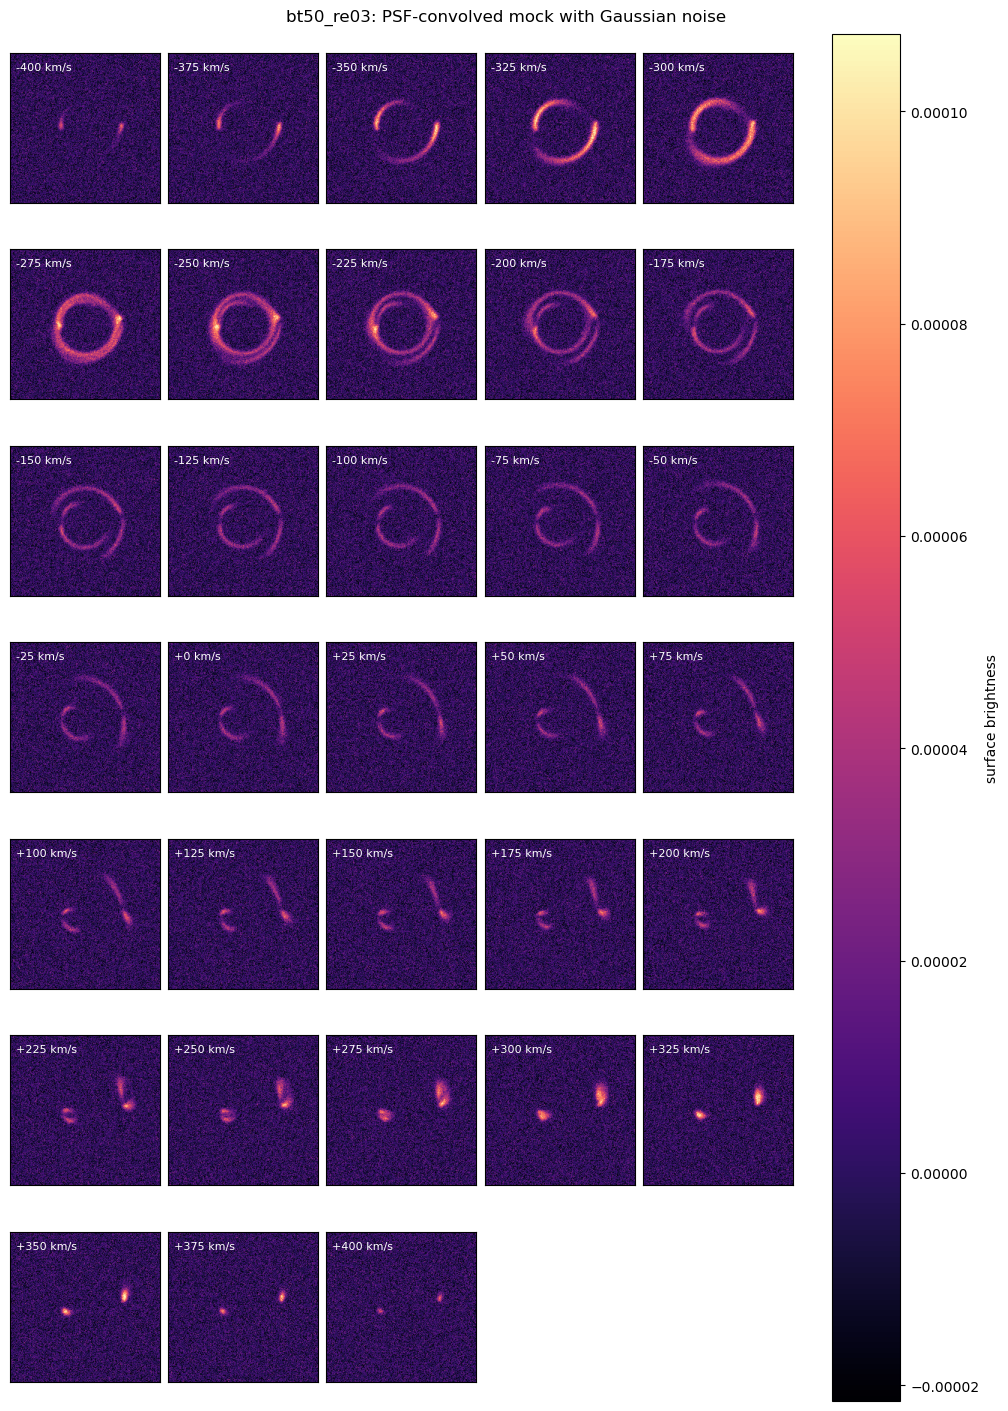

In [16]:
def plot_mock_channel_maps(cube, case_name, noise_sigma, label, ncols=5):
    nchan = cube.shape[0]
    nrows = int(np.ceil(nchan / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    image = None
    for index, ax in enumerate(axes):
        if index >= nchan:
            ax.set_visible(False)
            continue
        image = ax.imshow(
            cube[index], origin='lower', cmap='magma',
            vmin=-2.0 * noise_sigma, vmax=10.0 * noise_sigma,
            extent=(axis[0], axis[-1], axis[0], axis[-1]),
        )
        ax.text(0.04, 0.94, f'{VELOCITY_CHANNELS_KMS[index]:+.0f} km/s',
                transform=ax.transAxes, ha='left', va='top', color='white', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.colorbar(image, ax=axes[:nchan].tolist(), label='surface brightness')
    fig.suptitle(f'{case_name}: {label}')
    plt.show()

for case in CASES:
    mock = MOCKS[case['name']]
    plot_mock_channel_maps(
        mock['data_cube'], case['name'], mock['noise_sigma'],
        label='PSF-convolved mock with Gaussian noise',
    )


## Likelihood, priors, and timing benchmark

Both models use uniform priors from the TOML file. The no-bulge model fixes $B/T=0$ and removes the now-meaningless bulge radius from its parameter space. The Gaussian normalization is retained in $\ln L$, although it cancels in the evidence difference.

In [17]:
def complete_parameters(theta, case, model_name):
    # まず全parameterをtruthで固定し、TOMLでfreeにしたものだけ上書きする。
    parameters = truth_parameters(case)
    if model_name == 'no_bulge':
        parameters['bulge_to_total'] = 0.0
    parameters.update(zip(MODEL_FREE_NAMES[model_name], np.asarray(theta, dtype=float), strict=True))
    return parameters

def prior_transform(unit_cube, model_name):
    # dynestyの単位cube [0, 1]を、TOMLで指定した一様priorへ変換する。
    names = MODEL_FREE_NAMES[model_name]
    lower = np.array([BOUNDS[name]['lower'] for name in names])
    upper = np.array([BOUNDS[name]['upper'] for name in names])
    return lower + np.asarray(unit_cube) * (upper - lower)

def make_loglikelihood(case, model_name):
    mock = MOCKS[case['name']]
    data = mock['data_cube'][FIT_MASK]
    sigma = mock['noise_sigma']
    log_normalization = data.size * np.log(2.0 * np.pi * sigma**2)
    def loglikelihood(theta):
        # 各voxelのnoiseが独立で、既知の同じsigmaを持つGaussian likelihood。
        model = observed_model_cube(complete_parameters(theta, case, model_name))[FIT_MASK]
        chi2 = np.sum(((data - model) / sigma) ** 2)
        return -0.5 * (chi2 + log_normalization)
    return loglikelihood

benchmark_loglike = make_loglikelihood(CASES[0], 'bulge')
benchmark_rng = np.random.default_rng(1234)
benchmark_points = [prior_transform(benchmark_rng.random(len(MODEL_FREE_NAMES['bulge'])), 'bulge') for _ in range(30)]
start = time.perf_counter()
for point in benchmark_points:
    benchmark_loglike(point)
SECONDS_PER_LOGLIKE = (time.perf_counter() - start) / len(benchmark_points)
print(f'{1e3 * SECONDS_PER_LOGLIKE:.2f} ms per likelihood evaluation ({1/SECONDS_PER_LOGLIKE:.1f} evaluations/s, one core)')

62.63 ms per likelihood evaluation (16.0 evaluations/s, one core)


## Dynamic nested sampling

`DynamicNestedSampler` allocates additional samples between evidence and posterior accuracy using `pfrac` from the TOML file. During parallel sampling, only the first cache-miss fit shows Dynesty's standard progress bar as a representative. Each case/model result is cached under `output/stage2/results/cache/`. A valid cache is loaded automatically, so repeated executions skip sampling and only regenerate tables and figures. Changes to the sampling configuration or relevant `glint` source invalidate the cache. The cache also stores the original settings and per-source hashes, so a stale cache reports what changed. Set `STAGE2_FORCE_REFIT=1` to ignore valid caches, `STAGE2_BENCHMARK_ONLY=1` to skip both sampling and cache loading, `STAGE2_MAX_CASES=1` to limit cases, or `STAGE2_MODELS=bulge` to select models. A normal execution runs all configured cases, including the optional B/T=0 mock, with both models. Only load cache files created by this notebook, because pickle files are not safe when obtained from an untrusted source.

In [18]:
def weighted_quantile(values, quantiles, weights):
    # Nested samplingの不均一なposterior weightを考慮した分位点。
    order = np.argsort(values)
    sorted_values = np.asarray(values)[order]
    cumulative = np.cumsum(np.asarray(weights)[order])
    cumulative /= cumulative[-1]
    return np.interp(quantiles, cumulative, sorted_values)

def run_nested_fit(case, model_name, task_seed, show_progress=False):
    names = MODEL_FREE_NAMES[model_name]
    loglikelihood = make_loglikelihood(case, model_name)
    start = time.perf_counter()
    # 1 fit内ではDynestyのproposal/likelihood評価をthread poolへ流す。
    # Forward modelのNumPy/SciPy処理はGILを解放するため、複数coreを利用できる。
    with ThreadPoolExecutor(max_workers=DYNESTY_WORKERS_PER_FIT) as dynesty_pool:
        results = run_dynamic_dynesty(
            loglikelihood, lambda u: prior_transform(u, model_name), len(names),
            nlive_init=dynesty_cfg['nlive_init'], nlive_batch=dynesty_cfg['nlive_batch'],
            dlogz_init=dynesty_cfg['dlogz_init'], pfrac=dynesty_cfg['pfrac'],
            evidence_threshold=dynesty_cfg['evidence_threshold'],
            target_n_effective=dynesty_cfg['target_n_effective'],
            max_batches=dynesty_cfg['max_batches'],
            bound=dynesty_cfg['bound'], sample=dynesty_cfg['sample'],
            rstate=np.random.default_rng(np.random.SeedSequence([dynesty_cfg['random_seed'], task_seed])),
            pool=dynesty_pool, queue_size=DYNESTY_WORKERS_PER_FIT,
            use_pool={'prior_transform': False},
            print_progress=show_progress,
        )
    elapsed = time.perf_counter() - start
    weights = np.exp(results.logwt - results.logz[-1])
    posterior = {}
    for column, name in enumerate(names):
        posterior[name] = weighted_quantile(results.samples[:, column], [0.16, 0.50, 0.84], weights)
    best_index = int(np.argmax(results.logl))
    # 診断cubeにはposterior中央値ではなくmaximum-likelihood sampleを使う。
    return {
        'results': results, 'weights': weights, 'posterior': posterior,
        'best_parameters': complete_parameters(results.samples[best_index], case, model_name),
        'logz': float(results.logz[-1]), 'logzerr': float(results.logzerr[-1]),
        'max_logl': float(results.logl[best_index]), 'ncall': int(np.sum(results.ncall)), 'elapsed_seconds': elapsed,
    }

def run_nested_task(task):
    case, model_name, task_seed, show_progress = task
    return case['name'], model_name, run_nested_fit(case, model_name, task_seed, show_progress)

# Model/likelihoodの意味を意図的に変えた時だけ手動で上げる。
CACHE_VERSION = 3

def stable_task_seed(case_name, model_name):
    # 並列実行順が変わっても各taskの乱数seedが変わらないようにする。
    digest = hashlib.sha256(f'{case_name}:{model_name}'.encode()).digest()
    return int.from_bytes(digest[:4], byteorder='little')

def sampling_metadata(case, model_name):
    """Cache判定に使うTOML設定と入力mock dataを記録する。"""
    return {
        'cache_version': CACHE_VERSION,
        'truth_config': TRUTH_CONFIG,
        # Worker counts affect runtime, not the statistical model, so changing
        # [parallel] does not invalidate an otherwise reusable fit result.
        'stage_config': {key: value for key, value in CONFIG.items() if key != 'parallel'},
        'case': case,
        'model_name': model_name,
        'stage1_lensed_sha256': MOCKS[case['name']]['lensed_sha256'],
    }

CACHE_IGNORED_METADATA_KEYS = {
    'source_hashes', 'function_hashes', 'dependency_hashes',
    'dynesty_version', 'numpy_version',
}

def cache_relevant_metadata(metadata):
    return {key: value for key, value in metadata.items()
            if key not in CACHE_IGNORED_METADATA_KEYS}

def sampling_fingerprint(metadata):
    serialized = json.dumps(
        cache_relevant_metadata(metadata), sort_keys=True,
        default=lambda value: value.item() if isinstance(value, np.generic) else str(value),
    )
    return hashlib.sha256(serialized.encode()).hexdigest()

def flatten_metadata(value, prefix=''):
    if isinstance(value, dict):
        flattened = {}
        for key, item in value.items():
            child = f'{prefix}.{key}' if prefix else str(key)
            flattened.update(flatten_metadata(item, child))
        return flattened
    return {prefix: value}

def metadata_differences(cached, current, max_items=12):
    if cached is None:
        return ['legacy cache has no metadata']
    old = flatten_metadata(cache_relevant_metadata(cached))
    new = flatten_metadata(cache_relevant_metadata(current))
    changed = []
    for key in sorted(set(old) | set(new)):
        if old.get(key) != new.get(key):
            changed.append(
                f'{key}: {old.get(key, "<missing>")!r} -> {new.get(key, "<missing>")!r}'
            )
    if len(changed) > max_items:
        changed = changed[:max_items] + [f'... and {len(changed) - max_items} more']
    return changed or ['fingerprint format changed']

def cache_path(case_name, model_name):
    return CACHE_DIR / f'{case_name}__{model_name}.pkl'

def load_cached_result(case_name, model_name, metadata):
    path = cache_path(case_name, model_name)
    if not path.exists():
        return None
    try:
        with path.open('rb') as handle:
            payload = pickle.load(handle)
    except (OSError, EOFError, pickle.UnpicklingError):
        print(f'{case_name:10s} {model_name:9s}: unreadable cache ignored')
        return None
    cached_metadata = payload.get('metadata')
    if (cached_metadata is not None
            and sampling_fingerprint(cached_metadata) == sampling_fingerprint(metadata)):
        return payload['result']
    changes = metadata_differences(payload.get('metadata'), metadata)
    print(f'{case_name:10s} {model_name:9s}: stale cache ignored')
    for change in changes:
        print(f'    {change}')
    return None

def save_cached_result(case_name, model_name, metadata, result):
    path = cache_path(case_name, model_name)
    temporary_path = path.with_suffix('.tmp')
    payload = {
        'fingerprint': sampling_fingerprint(metadata),
        'metadata': metadata,
        'result': result,
    }
    with temporary_path.open('wb') as handle:
        pickle.dump(payload, handle, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(temporary_path, path)

RESULTS = {}
BENCHMARK_ONLY = os.getenv('STAGE2_BENCHMARK_ONLY', '0') == '1'
if not BENCHMARK_ONLY:
    max_cases = int(os.getenv('STAGE2_MAX_CASES', str(len(CASES))))
    run_models = tuple(name.strip() for name in os.getenv('STAGE2_MODELS', 'no_bulge,bulge').split(','))
    if not set(run_models) <= set(MODEL_FREE_NAMES):
        raise ValueError(f'Unknown STAGE2_MODELS value: {run_models}')
    run_cases = CASES[:max_cases]
    force_refit = os.getenv('STAGE2_FORCE_REFIT', '0') == '1'
    tasks = []
    task_metadata = {}
    # 1 taskは「1 physical case × 1 model」。Cache missだけを並列実行する。
    for case, model_name in product(run_cases, run_models):
        key = (case['name'], model_name)
        metadata = sampling_metadata(case, model_name)
        task_metadata[key] = metadata
        cached_result = None if force_refit else load_cached_result(*key, metadata)
        if cached_result is None:
            # 先頭のcache-miss fitだけDynesty標準の進捗を表示する。
            tasks.append((case, model_name, stable_task_seed(*key), len(tasks) == 0))
        else:
            RESULTS.setdefault(case['name'], {})[model_name] = cached_result
            print(f'{case["name"]:10s} {model_name:9s}: loaded valid cache')
    total_start = time.perf_counter()
    if tasks:
        available_cpus = os.cpu_count() or 1
        configured_workers = int(parallel_cfg['max_workers'])
        max_workers = min(
            configured_workers,
            max(1, available_cpus // DYNESTY_WORKERS_PER_FIT),
            len(tasks),
        )
        total_workers = max_workers * DYNESTY_WORKERS_PER_FIT
        print(
            f'running {len(tasks)} cache-miss fits: {max_workers} concurrent fits x '
            f'{DYNESTY_WORKERS_PER_FIT} Dynesty workers = {total_workers} workers'
        )
        # dynesty fitはprocess単位で並列化し、各process内の数値libraryは1 threadに制限する。
        if max_workers == 1:
            completed_tasks = map(run_nested_task, tasks)
            pool = None
        else:
            context = mp.get_context(parallel_cfg['start_method'])
            pool = context.Pool(processes=max_workers)
            completed_tasks = pool.imap_unordered(run_nested_task, tasks, chunksize=1)
        try:
            for case_name, model_name, result in completed_tasks:
                RESULTS.setdefault(case_name, {})[model_name] = result
                save_cached_result(case_name, model_name, task_metadata[(case_name, model_name)], result)
                print(f"{case_name:10s} {model_name:9s}: lnZ={result['logz']:.2f} +/- {result['logzerr']:.2f}, calls={result['ncall']:,}, fit time={result['elapsed_seconds']/60:.1f} min; cache saved")
        finally:
            if pool is not None:
                pool.close()
                pool.join()
    else:
        print('all requested fits loaded from valid caches; dynesty sampling skipped')
    print(f'total sampling/cache wall time = {(time.perf_counter()-total_start)/60:.2f} min')
else:
    print('Benchmark-only mode: nested sampling skipped.')

bt50_re03  no_bulge : loaded valid cache
bt50_re03  bulge    : loaded valid cache
all requested fits loaded from valid caches; dynesty sampling skipped
total sampling/cache wall time = 0.00 min


## Evidence and parameter summary

The bulge model uses a continuous prior down to `B/T = 0`. Although its model family approaches the no-bulge model at that boundary, the exact boundary has zero probability under a continuous prior. The evidence therefore remains a meaningful comparison: an unnecessary bulge is penalized through the extra prior volume (the Occam factor). The numerical Bayes factor is nevertheless prior-dependent, so the adopted upper bound and prior shape should be reported and later tested for sensitivity. A positive lower bound would answer a different question—whether a bulge larger than that imposed minimum is required.


case,B/T truth,Re truth [kpc],lnZ no bulge,lnZ bulge,Delta lnZ,Delta lnZ numerical error
str9,float64,float64,float64,float64,float64,float64
bt50_re03,0.500,0.300,13220892.961,13231784.579,10891.619,0.474


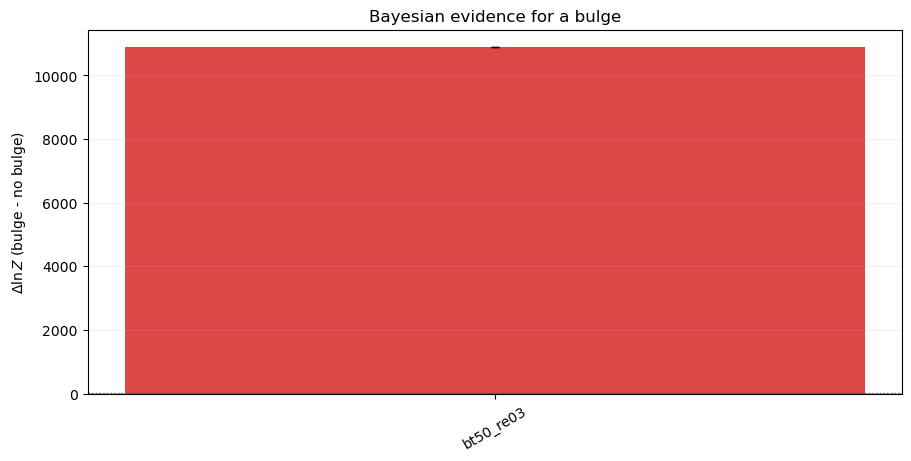

In [19]:
FULL_RESULTS = len(RESULTS) == len(CASES) and all(set(result) == {'no_bulge', 'bulge'} for result in RESULTS.values())
# 全case・両modelが揃ったときだけevidence比較と一括診断を作る。
if FULL_RESULTS:
    rows = []
    for case in CASES:
        no_bulge = RESULTS[case['name']]['no_bulge']
        bulge = RESULTS[case['name']]['bulge']
        rows.append((case['name'], case['bulge_to_total'], case['bulge_effective_radius_kpc'], no_bulge['logz'], bulge['logz'], bulge['logz'] - no_bulge['logz'], np.hypot(no_bulge['logzerr'], bulge['logzerr'])))
        # 独立なlnZ誤差を仮定し、Delta lnZの数値誤差は二乗和平方根で評価する。
    EVIDENCE_TABLE = Table(rows=rows, names=('case', 'B/T truth', 'Re truth [kpc]', 'lnZ no bulge', 'lnZ bulge', 'Delta lnZ', 'Delta lnZ numerical error'))
    for name in EVIDENCE_TABLE.colnames[1:]: EVIDENCE_TABLE[name].format = '.3f'
    display(EVIDENCE_TABLE)

    fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
    delta = np.asarray(EVIDENCE_TABLE['Delta lnZ'])
    error = np.asarray(EVIDENCE_TABLE['Delta lnZ numerical error'])
    colors = ['tab:blue' if value < 2.5 else 'tab:orange' if value < 5 else 'tab:red' for value in delta]
    ax.bar(np.arange(len(CASES)), delta, yerr=error, color=colors, alpha=0.85, capsize=3)
    ax.axhline(0, color='black', lw=1)
    ax.axhline(2.5, color='0.4', lw=1, ls='--')
    ax.axhline(5.0, color='0.4', lw=1, ls=':')
    ax.set_xticks(np.arange(len(CASES)), [case['name'] for case in CASES], rotation=30)
    ax.set_ylabel(r'$\Delta\ln Z$ (bulge - no bulge)')
    ax.set_title('Bayesian evidence for a bulge')
    ax.grid(axis='y', alpha=0.2)
    plt.show()

## Rotation curves and residual diagnostics

Solid black is the truth, red is the maximum-likelihood bulge model, and blue is the maximum-likelihood no-bulge model. The light red/blue bands show the 16th--84th percentile range obtained by propagating joint weighted-posterior samples through the physical rotation-curve model.

A second rotation-curve figure separates the total, disk, bulge, and halo contributions. Solid curves are truth; dashed curves with points are maximum-likelihood fits. Residual moment maps are summed over velocity after subtracting the corresponding convolved model cube. All three summary figures are also saved as PDF under `output/stage2/results/figures/`.

saved output/stage2/results/figures/rotation_curves_total.pdf


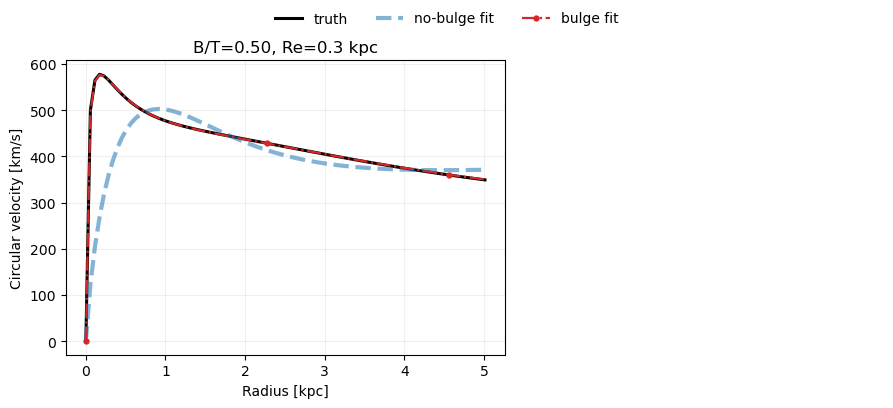

saved output/stage2/results/figures/rotation_curves_components.pdf


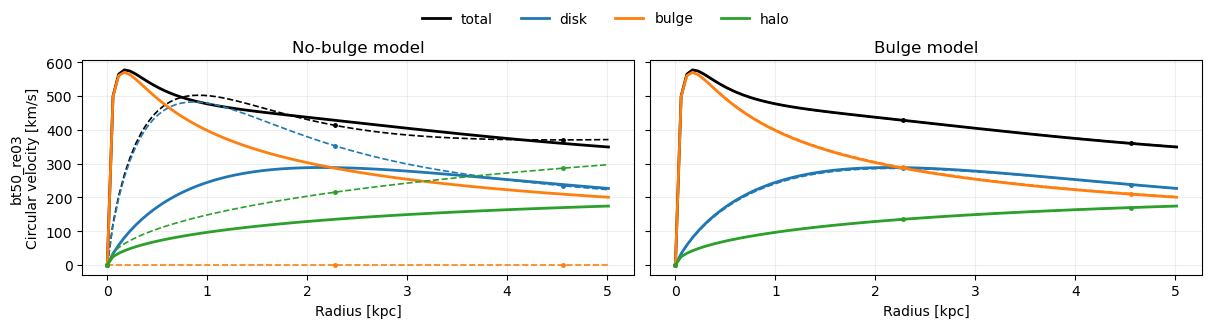

saved output/stage2/results/figures/bestfit_moment0_residual_comparison.pdf


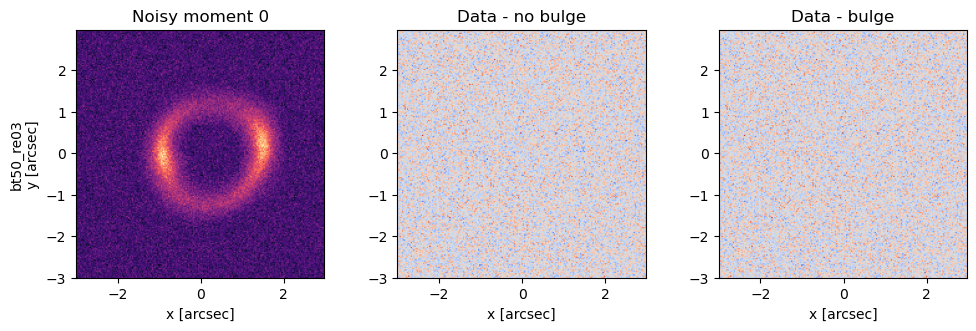

In [20]:
def posterior_rotation_curve_interval(case, model_name, max_samples=2000):
    """Dynestyのjoint posteriorを回転曲線へ伝播し、16/50/84 percentileを返す。"""
    result = RESULTS[case['name']][model_name]
    samples = np.asarray(result['results'].samples)
    weights = np.asarray(result['weights'], dtype=float)
    weights /= weights.sum()

    # 全sampleの重みを保ったまま、描画に十分な数へ再samplingする。
    sample_count = min(max_samples, samples.shape[0])
    rng = np.random.default_rng(stable_task_seed(case['name'], model_name) + 104729)
    indices = rng.choice(samples.shape[0], size=sample_count, replace=True, p=weights)
    curves = np.empty((sample_count, RADIUS_KPC.size), dtype=float)
    for row, sample_index in enumerate(indices):
        parameters = complete_parameters(samples[sample_index], case, model_name)
        curves[row] = rotation_curve(parameters)['total_kms']
    return np.percentile(curves, (16.0, 50.0, 84.0), axis=0)


if FULL_RESULTS:
    ncols = 3
    nrows = int(np.ceil(len(CASES) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True, sharey=True, squeeze=False, constrained_layout=True)
    for ax, case in zip(axes.flat, CASES):
        ax.plot(RADIUS_KPC, rotation_curve(case)['total_kms'], color='black', lw=2.2, label='truth')
        fit_styles = {
            'no_bulge': dict(color='tab:blue', lw=3.0, ls='--', alpha=0.55, zorder=2, label='no-bulge fit'),
            'bulge': dict(color='tab:red', lw=1.6, ls='-.', marker='o', markevery=40, ms=3.5, zorder=3, label='bulge fit'),
        }
        band_styles = {
            'no_bulge': dict(color='tab:blue', alpha=0.14, linewidth=0, zorder=1),
            'bulge': dict(color='tab:red', alpha=0.14, linewidth=0, zorder=1),
        }
        # Draw the broad no-bulge curve first and the marked bulge curve last so coincident fits remain visible.
        for model_name in ('no_bulge', 'bulge'):
            lower, median, upper = posterior_rotation_curve_interval(case, model_name)
            ax.fill_between(RADIUS_KPC, lower, upper, **band_styles[model_name])
            curve = rotation_curve(RESULTS[case['name']][model_name]['best_parameters'])
            ax.plot(RADIUS_KPC, curve['total_kms'], **fit_styles[model_name])
        title = 'B/T=0 (no bulge)' if case['bulge_to_total'] == 0 else f"B/T={case['bulge_to_total']:.2f}, Re={case['bulge_effective_radius_kpc']:.1f} kpc"
        ax.set_title(title)
        ax.grid(alpha=0.2)
    for ax in axes.flat[len(CASES):]: ax.set_visible(False)
    for ax in axes[:, 0]: ax.set_ylabel('Circular velocity [km/s]')
    for ax in axes[-1]: ax.set_xlabel('Radius [kpc]')
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside upper center', ncol=3, frameon=False)
    total_curve_path = FIGURE_DIR / 'rotation_curves_total.pdf'
    fig.savefig(total_curve_path, bbox_inches='tight')
    print(f'saved {total_curve_path.relative_to(EXAMPLE_DIR)}')
    plt.show()

    # Stage 1と同じ色分けで、各mass componentのtruthとbest fitを比較する。
    component_colors = {
        'total': 'black', 'disk': 'tab:blue',
        'bulge': 'tab:orange', 'halo': 'tab:green',
    }
    fig, axes = plt.subplots(
        len(CASES), 2, figsize=(12, 3.2 * len(CASES)),
        sharex=True, sharey=True, squeeze=False, constrained_layout=True,
    )
    for row, case in enumerate(CASES):
        truth_curve = rotation_curve(case)
        for column, model_name in enumerate(('no_bulge', 'bulge')):
            ax = axes[row, column]
            best_curve = rotation_curve(RESULTS[case['name']][model_name]['best_parameters'])
            for component, color in component_colors.items():
                key = f'{component}_kms'
                label = component if row == 0 and column == 0 else None
                ax.plot(RADIUS_KPC, truth_curve[key], color=color, lw=2.0, label=label)
                ax.plot(
                    RADIUS_KPC, best_curve[key], color=color, lw=1.2, ls='--',
                    marker='o', markersize=2.5, markevery=40,
                )
            ax.grid(alpha=0.2)
            if column == 0:
                ax.set_ylabel(f"{case['name']}\nCircular velocity [km/s]")
    axes[0, 0].set_title('No-bulge model')
    axes[0, 1].set_title('Bulge model')
    for ax in axes[-1]:
        ax.set_xlabel('Radius [kpc]')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside upper center', ncol=4, frameon=False)
    component_curve_path = FIGURE_DIR / 'rotation_curves_components.pdf'
    fig.savefig(component_curve_path, bbox_inches='tight')
    print(f'saved {component_curve_path.relative_to(EXAMPLE_DIR)}')
    plt.show()

    fig, axes = plt.subplots(
        len(CASES), 3, figsize=(10, 3.2 * len(CASES)),
        squeeze=False, constrained_layout=True,
    )
    extent = [axis.min(), axis.max(), axis.min(), axis.max()]
    for row, case in enumerate(CASES):
        mock = MOCKS[case['name']]
        data_moment0 = mock['data_cube'].sum(axis=0)
        residuals = {}
        for model_name in ('no_bulge', 'bulge'):
            model_cube = observed_model_cube(RESULTS[case['name']][model_name]['best_parameters'])
            residuals[model_name] = (mock['data_cube'] - model_cube).sum(axis=0)
        limit = max(np.max(np.abs(residuals['no_bulge'])), np.max(np.abs(residuals['bulge'])))
        axes[row, 0].imshow(data_moment0, origin='lower', extent=extent, cmap='magma')
        axes[row, 1].imshow(residuals['no_bulge'], origin='lower', extent=extent, cmap='coolwarm', vmin=-limit, vmax=limit)
        axes[row, 2].imshow(residuals['bulge'], origin='lower', extent=extent, cmap='coolwarm', vmin=-limit, vmax=limit)
        axes[row, 0].set_ylabel(case['name'] + '\ny [arcsec]')
    for ax, title in zip(axes[0], ('Noisy moment 0', 'Data - no bulge', 'Data - bulge'), strict=True): ax.set_title(title)
    for ax in axes[-1]: ax.set_xlabel('x [arcsec]')
    image_comparison_path = FIGURE_DIR / 'bestfit_moment0_residual_comparison.pdf'
    fig.savefig(image_comparison_path, bbox_inches='tight')
    print(f'saved {image_comparison_path.relative_to(EXAMPLE_DIR)}')
    plt.show()

## Saved fit and convergence diagnostics

For every case and model, `dynesty.plotting.runplot`, `cornerplot`, and a full 27-channel cube comparison are saved under `output/stage2/results/figures/<case>/<model>/`. The four cube columns are noisy true observed data, PSF-convolved maximum-likelihood model data, standardized residual $(D-M)/\sigma$, and reconstructed intrinsic source before PSF convolution. A successful noise-limited fit should have residual RMS and reduced $\chi^2$ near one; the residual cube is not expected to be zero because the mock contains noise.

In [21]:
if FULL_RESULTS:
    save_dynesty_diagnostic_plots()
    FIT_DIAGNOSTICS = save_channel_diagnostics()

/home/tsujtaak/miniconda3/envs/jaxlens/lib/python3.12/site-packages/dynesty/utils.py:1167: UserWarning: Weights do not sum to 1 and have been renormalized.
  warnings.warn("Weights do not sum to 1 and have been renormalized.")


saved output/stage2/results/figures/bt50_re03/no_bulge/dynesty_runplot.pdf and output/stage2/results/figures/bt50_re03/no_bulge/dynesty_cornerplot.pdf
saved output/stage2/results/figures/bt50_re03/bulge/dynesty_runplot.pdf and output/stage2/results/figures/bt50_re03/bulge/dynesty_cornerplot.pdf
saved output/stage2/results/figures/bt50_re03/no_bulge/all_channel_cube_comparison.pdf
saved output/stage2/results/figures/bt50_re03/bulge/all_channel_cube_comparison.pdf


case,model,chi2,dof,reduced_chi2,residual_mean_sigma,residual_std_sigma,max_abs_residual_sigma
str9,str8,float64,int64,float64,float64,float64,float64
bt50_re03,no_bulge,1.3403e+06,1.32e+06,1.0154,-0.0019397,1.0076,8.636
bt50_re03,bulge,1.3183e+06,1.32e+06,0.99875,-0.0013154,0.99937,4.8192


saved output/stage2/results/fit_diagnostics.csv


## Interpretation

For the B/T=0 mock, the no-bulge model should normally be favored after the evidence penalizes the two unnecessary bulge parameters. Its configured bulge radius is only a positive placeholder and has no physical meaning. A small $\Delta\ln Z$ for a true bulge does not by itself indicate a code failure: at finite resolution and S/N, a compact or low-mass bulge can be absorbed by disk and halo parameters. Evidence is prior-dependent, so the numerical result must always be quoted together with `mock_stage2.toml`.